In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize, window_table
from src.strategy import momentum_trend_strategy, momentum_volatility_strategy, momentum_voluratio_strategy
from src.visualization import plot_performance, plot_features

In [2]:
base_df = get_data('AAPL', '2021-01-01', '2026-01-01')
base_df = generate_features(base_df)

[*********************100%***********************]  1 of 1 completed


# Features 

/Users/noel/Desktop/quant-research-system/src/visualization.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


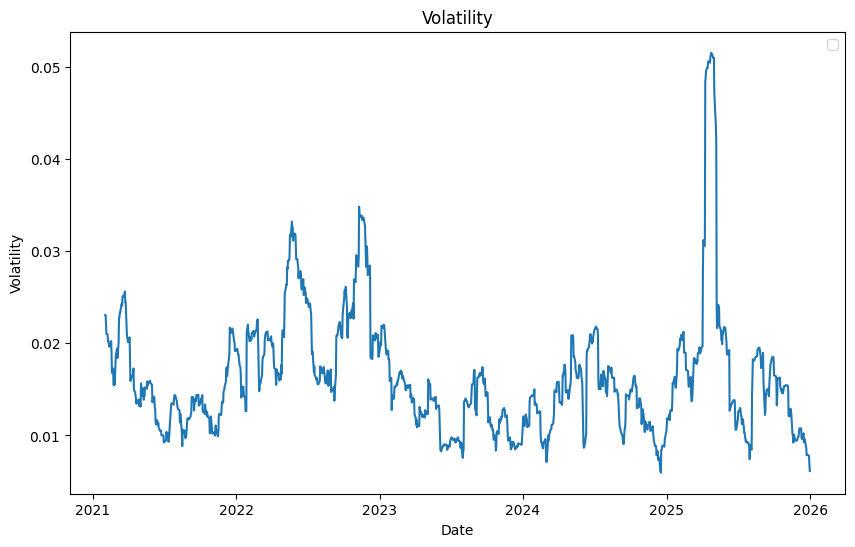

/Users/noel/Desktop/quant-research-system/src/visualization.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


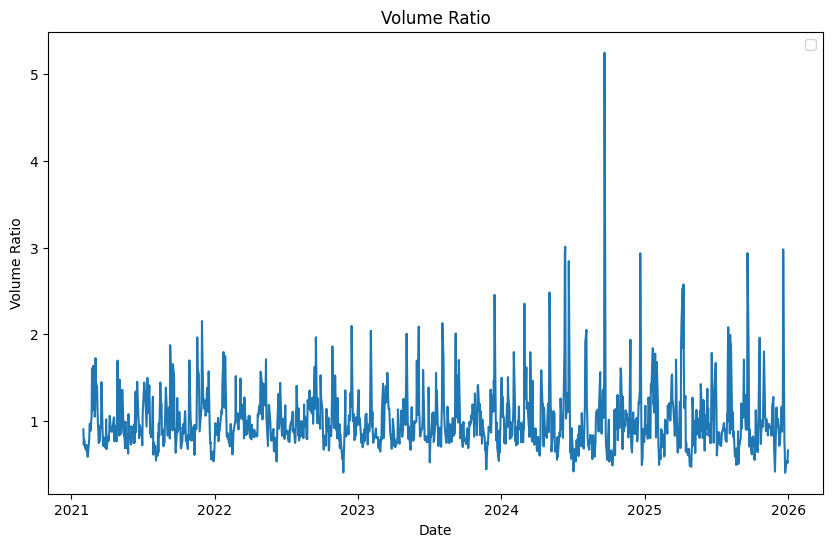

/Users/noel/Desktop/quant-research-system/src/visualization.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


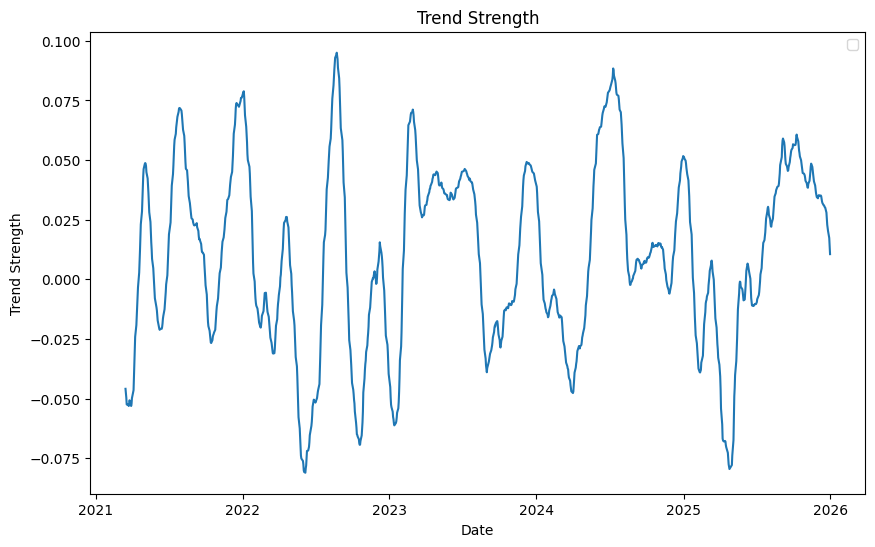

In [3]:
plot_features(base_df)

# Filtered Strategies

## Momentum + Trend Strategy

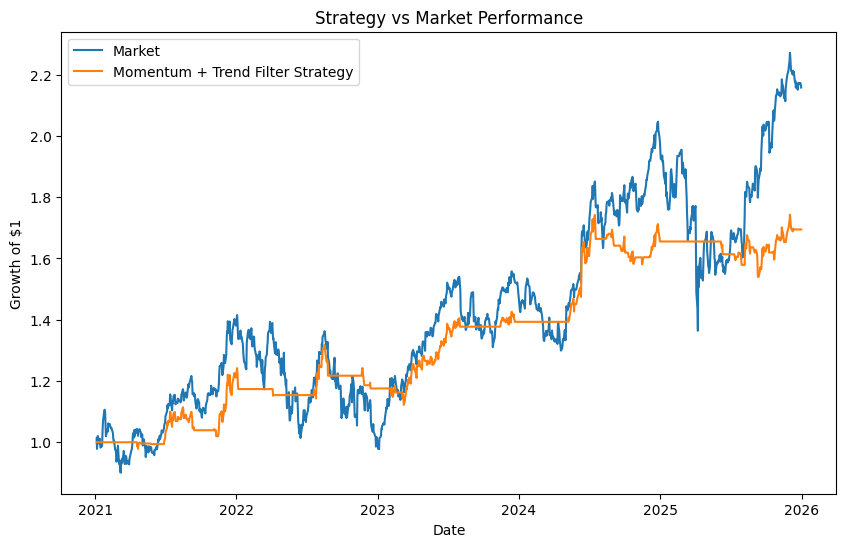

In [4]:
df = base_df.copy()
df = momentum_trend_strategy(df)
df = backtest(df)

plot_performance(df)

In [5]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum + Trend Filter,0.921788,0.123169,-0.148499


## Momentum + Low Volatility Strategy

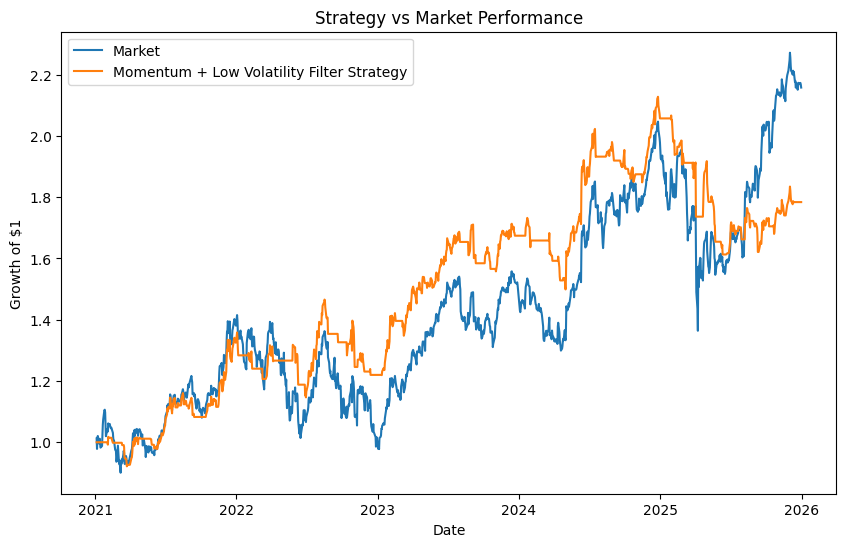

In [6]:
df = base_df.copy()
df = momentum_volatility_strategy(df)
df = backtest(df)

plot_performance(df)

In [7]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum + Low Volatility Filter,0.742796,0.177896,-0.241998


## Momentum + Volume Ratio Strategy

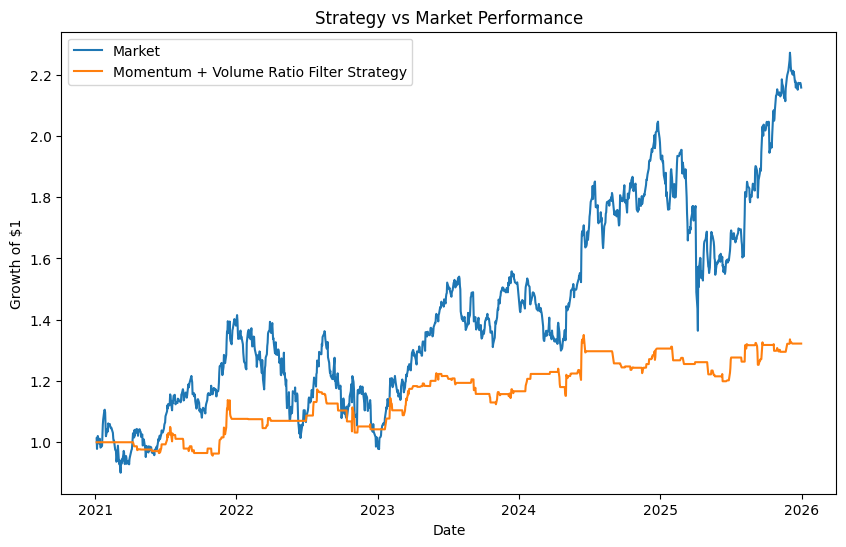

In [8]:
df = base_df.copy()
df = momentum_voluratio_strategy(df)
df = backtest(df)

plot_performance(df)

In [9]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum + Volume Ratio Filter,0.547271,0.114331,-0.120215


# Parameter Testing

In [10]:
windows = range(1, 51)
strategies = [
    ("Momentum + Trend Strength", momentum_trend_strategy, "mo_tr", None),
    ("Momentum + Rolling Volatility", momentum_volatility_strategy, "mo_vo", None),
    ("Momentum + Volume Ratio", momentum_voluratio_strategy, "mo_vr", None)
]

In [11]:
df = base_df.copy()
window_table(df, strategies, [5, 10, 20, 50])

,Strategy,Window,Sharpe,Volatility,Max DD
0,Momentum + Volume Ratio,5,0.588996,0.118049,-0.123591
1,Momentum + Volume Ratio,10,0.547271,0.114331,-0.120215
2,Momentum + Volume Ratio,20,0.833536,0.117243,-0.170011
3,Momentum + Volume Ratio,50,0.490775,0.120599,-0.204806


Momentum + Trend Strength
Market Sharpe Ratio: 0.6935
Best Momentum + Trend Strength Strategy window: 14
Best Sharpe ratio: 1.0088


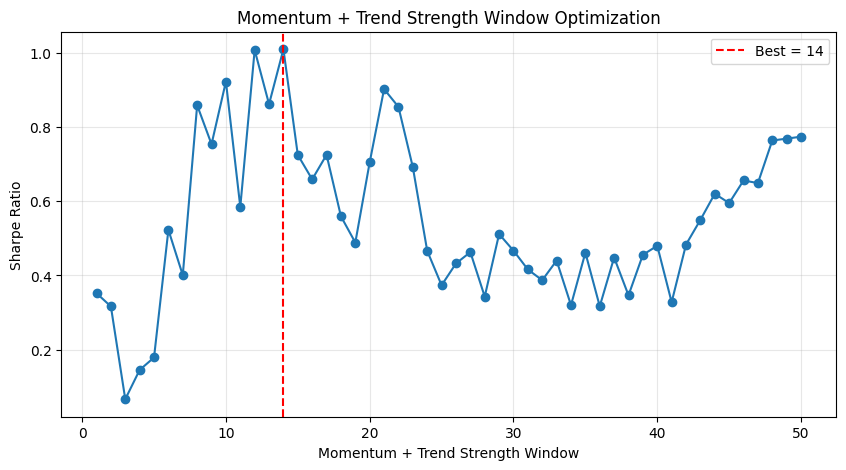

Momentum + Rolling Volatility
Market Sharpe Ratio: 0.6935
Best Momentum + Rolling Volatility Strategy window: 14
Best Sharpe ratio: 1.0585


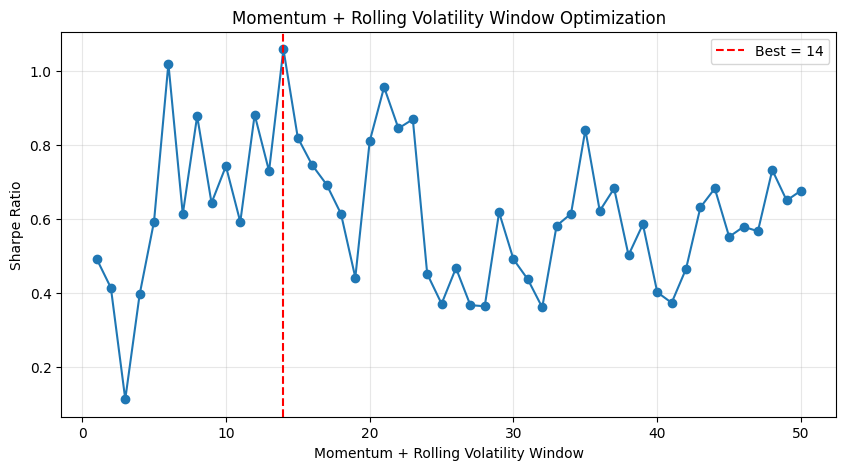

Momentum + Volume Ratio
Market Sharpe Ratio: 0.6935
Best Momentum + Volume Ratio Strategy window: 21
Best Sharpe ratio: 0.9501


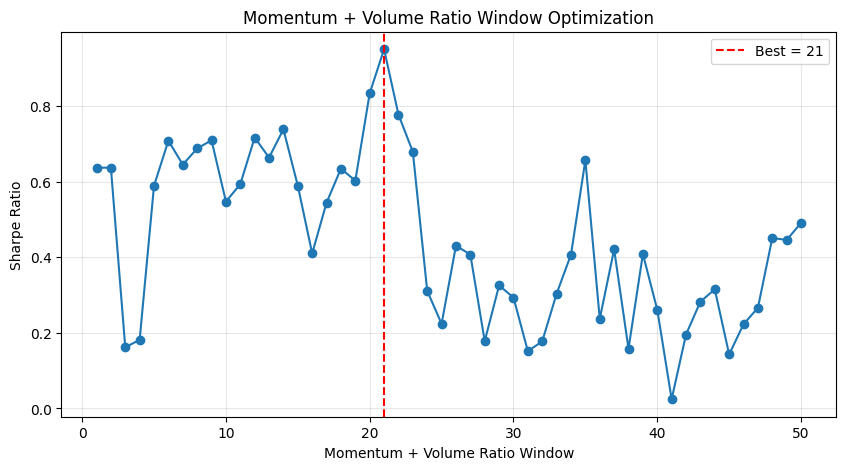

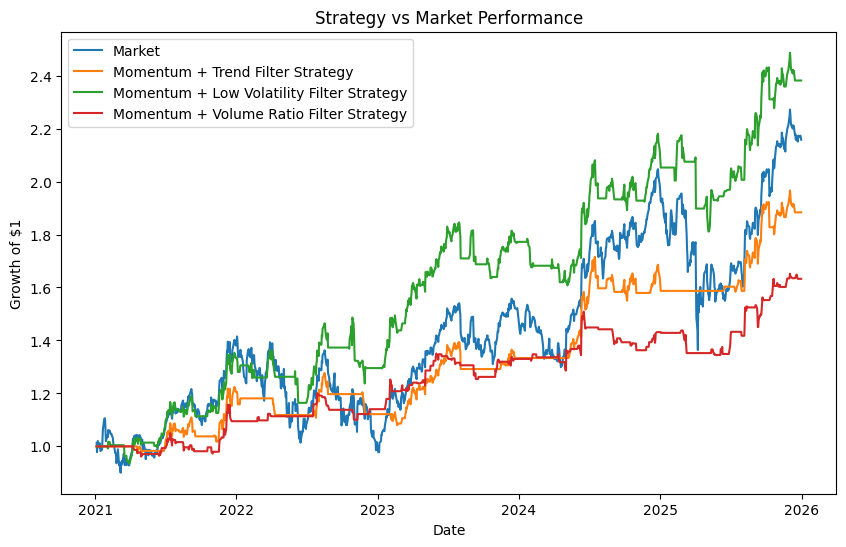

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum + Trend Filter,1.008841,0.135120,-0.154756
2,Momentum + Low Volatility Filter,1.058523,0.180032,-0.169209
3,Momentum + Volume Ratio Filter,0.950099,0.109975,-0.108301


In [12]:
df = base_df.copy()

optimize(df, strategies, windows)